In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
!pip install -q albumentations opencv-python

In [28]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [30]:
DATA_ROOT = "/content/drive/MyDrive/Project Data/Fruit"

TRAIN_DIR = os.path.join(DATA_ROOT, "Train")
VAL_DIR   = os.path.join(DATA_ROOT, "Validation")


In [31]:
classes = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print("Number of classes:", len(classes))
print(classes)


Number of classes: 30
['Apple_Gala', 'Apple_Golden Delicious', 'Avocado', 'Banana', 'Berry', 'Burmese Grape', 'Carambola', 'Date Palm', 'Dragon', 'Elephant Apple', 'Grape', 'Green Coconut', 'Guava', 'Hog Plum', 'Kiwi', 'Lichi', 'Malta', 'Mango Golden Queen', 'Mango_Alphonso', 'Mango_Amrapali', 'Mango_Bari', 'Mango_Himsagar', 'Olive', 'Orange', 'Palm', 'Persimmon', 'Pineapple', 'Pomegranate', 'Watermelon', 'White Pear']


In [32]:
class_to_id = {cls: i + 1 for i, cls in enumerate(classes)}
id_to_class = {v: k for k, v in class_to_id.items()}

print(class_to_id)


{'Apple_Gala': 1, 'Apple_Golden Delicious': 2, 'Avocado': 3, 'Banana': 4, 'Berry': 5, 'Burmese Grape': 6, 'Carambola': 7, 'Date Palm': 8, 'Dragon': 9, 'Elephant Apple': 10, 'Grape': 11, 'Green Coconut': 12, 'Guava': 13, 'Hog Plum': 14, 'Kiwi': 15, 'Lichi': 16, 'Malta': 17, 'Mango Golden Queen': 18, 'Mango_Alphonso': 19, 'Mango_Amrapali': 20, 'Mango_Bari': 21, 'Mango_Himsagar': 22, 'Olive': 23, 'Orange': 24, 'Palm': 25, 'Persimmon': 26, 'Pineapple': 27, 'Pomegranate': 28, 'Watermelon': 29, 'White Pear': 30}


In [33]:
sample_class = classes[0]

img_dir  = os.path.join(TRAIN_DIR, sample_class, "Images")
mask_dir = os.path.join(TRAIN_DIR, sample_class, "Mask")


In [ ]:
def load_image_and_mask(img_path, mask_dir):

    img_name_noext = os.path.splitext(os.path.basename(img_path))[0]

    mask_files = os.listdir(mask_dir)
    mask_name = None
    for f in mask_files:
        if f.startswith(img_name_noext):
            mask_name = f
            break

    if mask_name is None:
        raise FileNotFoundError(f"No mask found for image {img_path}")

    mask_path = os.path.join(mask_dir, mask_name)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    return image, mask



Image shape: (512, 512, 3)
Mask shape: (512, 512)
Mask unique values: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 2

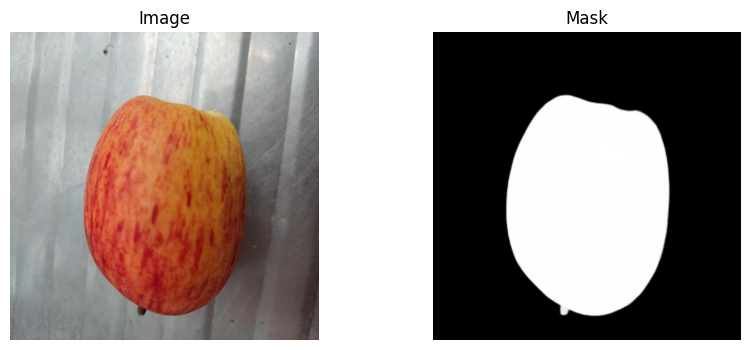

In [35]:

image, mask = load_image_and_mask(img_path, mask_dir)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", np.unique(mask))

image, mask = load_image_and_mask(img_path, mask_dir)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", np.unique(mask))


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()



In [ ]:
def binary_to_multiclass_mask(binary_mask, class_name, class_to_id):
    class_id = class_to_id[class_name]

    mask_multiclass = np.zeros_like(binary_mask, dtype=np.uint8)
    mask_multiclass[binary_mask > 0] = class_id

    return mask_multiclass


Unique values in multiclass mask: [0 1]


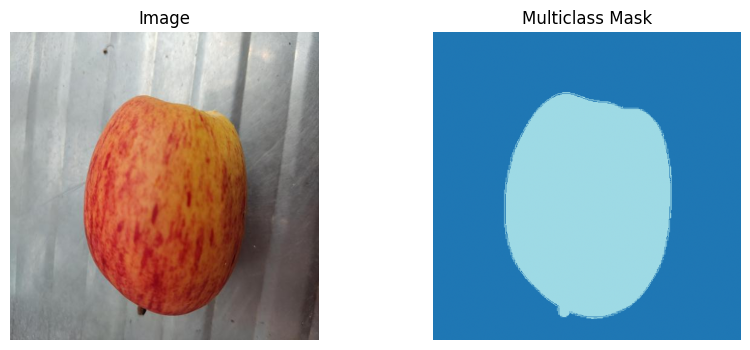

In [37]:
multiclass_mask = binary_to_multiclass_mask(mask, sample_class, class_to_id)

print("Unique values in multiclass mask:", np.unique(multiclass_mask))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(multiclass_mask, cmap="tab20")
plt.title("Multiclass Mask")
plt.axis("off")
plt.show()


In [ ]:
train_image_paths = []
train_mask_paths = []

for cls in classes:
    img_dir = os.path.join(TRAIN_DIR, cls, "Images")
    mask_dir = os.path.join(TRAIN_DIR, cls, "Mask")

    for img_name in os.listdir(img_dir):
        img_path = os.path.join(img_dir, img_name)
        train_image_paths.append(img_path)
        train_mask_paths.append((mask_dir, cls)) 


In [39]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
class FruitSegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_info, class_to_id, transform=None, img_size=(512,512)):
        self.image_paths = image_paths
        self.mask_info = mask_info
        self.class_to_id = class_to_id
        self.transform = transform
        self.img_size = img_size 

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_dir, class_name = self.mask_info[idx]

        image, mask_binary = load_image_and_mask(img_path, mask_dir)
        mask = binary_to_multiclass_mask(mask_binary, class_name, self.class_to_id)

        import cv2
        image = cv2.resize(image, self.img_size[::-1]) 
        mask  = cv2.resize(mask, self.img_size[::-1], interpolation=cv2.INTER_NEAREST)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']

        image = torch.tensor(image, dtype=torch.float).permute(2,0,1) / 255.0
        mask  = torch.tensor(mask, dtype=torch.long)

        return image, mask


In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.2,
        rotate_limit=25,
        p=0.7
    ),

    A.RandomBrightnessContrast(p=0.6),
    A.HueSaturationValue(p=0.5),

    A.GaussianBlur(p=0.2),
    A.CoarseDropout(
        max_holes=8,
        max_height=32,
        max_width=32,
        p=0.3
    ),
])

val_transform = None 


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1016391783.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [ ]:

train_image_paths = []
train_mask_info   = []

for cls in classes:
    img_dir = os.path.join(TRAIN_DIR, cls, "Images")
    mask_dir = os.path.join(TRAIN_DIR, cls, "Mask")

    for img_name in os.listdir(img_dir):
        img_path = os.path.join(img_dir, img_name)
        train_image_paths.append(img_path)
        train_mask_info.append((mask_dir, cls))


val_image_paths = []
val_mask_info = []

for cls in classes:
    img_dir = os.path.join(VAL_DIR, cls, "Images")
    mask_dir = os.path.join(VAL_DIR, cls, "Mask")

    for img_name in os.listdir(img_dir):
        img_path = os.path.join(img_dir, img_name)
        val_image_paths.append(img_path)
        val_mask_info.append((mask_dir, cls))


In [43]:
BATCH_SIZE = 4

train_dataset = FruitSegmentationDataset(train_image_paths, train_mask_info, class_to_id, transform=train_transform, img_size=(512,512))
val_dataset   = FruitSegmentationDataset(val_image_paths, val_mask_info, class_to_id, transform=val_transform, img_size=(512,512))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [ ]:
images, masks = next(iter(train_loader))
print("Images shape:", images.shape)  
print("Masks shape :", masks.shape)   
print("Mask unique values in batch:", torch.unique(masks))


Images shape: torch.Size([4, 3, 512, 512])
Masks shape : torch.Size([4, 512, 512])
Mask unique values in batch: tensor([ 0,  5, 22, 24])


In [45]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [ ]:
from torchvision.models import resnet34

class UNetResNet34(nn.Module):
    def __init__(self, n_classes=31, pretrained=True):
        super().__init__()
        self.encoder = resnet34(pretrained=pretrained)
        self.encoder_layers = list(self.encoder.children())


        self.enc1 = nn.Sequential(*self.encoder_layers[:3])   
        self.enc2 = nn.Sequential(*self.encoder_layers[3:5])   
        self.enc3 = self.encoder_layers[5]                    
        self.enc4 = self.encoder_layers[6]                  
        self.enc5 = self.encoder_layers[7]               

        
        self.up5 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec5 = nn.Conv2d(512, 256, 3, padding=1)
        self.up4 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec4 = nn.Conv2d(256, 128, 3, padding=1)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = nn.Conv2d(128, 64, 3, padding=1)
        self.up2 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec2 = nn.Conv2d(128, 64, 3, padding=1)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Conv2d(32, 32, 3, padding=1)

        
        self.final = nn.Conv2d(32, n_classes, kernel_size=1)

        self.relu = nn.ReLU(inplace=True)

        self.drop5 = nn.Dropout2d(p=0.3)
        self.drop4 = nn.Dropout2d(p=0.3)
        self.drop3 = nn.Dropout2d(p=0.2)


    def forward(self, x):
        
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        
        d5 = self.up5(e5)
        d5 = self.dec5(torch.cat([d5, e4], dim=1))
        d5 = self.drop5(d5)

        d4 = self.up4(d5)
        d4 = self.dec4(torch.cat([d4, e3], dim=1))
        d4 = self.drop4(d4)

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e2], dim=1))
        d3 = self.drop3(d3)

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e1], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(d1)

        out = self.final(d1)
        return out

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNetResNet34(n_classes=31).to(device)

criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)


In [ ]:
from tqdm import tqdm

EPOCHS = 20
best_iou = 0.0

MODEL_DIR = "/content/drive/MyDrive/FruitSegmentationModels"
os.makedirs(MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_model.pth")

for epoch in range(EPOCHS):
 
    model.train()
    train_loss = 0
    train_loader_tq = tqdm(train_loader, desc=f"Train {epoch+1}", leave=False)
    for images, masks in train_loader_tq:
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    
    model.eval()
    val_loss = 0
    val_iou = 0
    val_dice = 0

    val_loader_tq = tqdm(val_loader, desc=f"Val {epoch+1}", leave=False)
    with torch.no_grad():
        for images, masks in val_loader_tq:
            images = images.to(device)
            masks  = masks.to(device)
            outputs = model(images)

            loss = criterion(outputs, masks)
            val_loss += loss.item()

           
            preds = torch.argmax(outputs, dim=1)
            intersection = (preds == masks).float().sum()
            union = masks.numel()
            val_iou += intersection / union
            val_dice += (2*intersection) / (2*intersection + (union - intersection))

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    
    print(f"Epoch {epoch+1}/{EPOCHS} — TrainLoss={train_loss:.4f}  ValLoss={val_loss:.4f}  IoU={val_iou:.4f}  Dice={val_dice:.4f}")

    
    patience = 4
    epochs_no_improve = 0

    if val_iou > best_iou:
        best_iou = val_iou
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Saved best model (IoU={best_iou:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break




Epoch 1/20 - TrainLoss=1.2227  ValLoss=1.2209  IoU=0.6514  Dice=0.7783
Saved best model (IoU=0.6514)
Epoch 2/20 - TrainLoss=1.1148  ValLoss=1.0726  IoU=0.6712  Dice=0.7915
Saved best model (IoU=0.6712)
Epoch 3/20 - TrainLoss=1.0612  ValLoss=1.0171  IoU=0.6763  Dice=0.7952
Saved best model (IoU=0.6763)
Epoch 4/20 - TrainLoss=1.0082  ValLoss=0.9777  IoU=0.6876  Dice=0.8045
Saved best model (IoU=0.6876)
Epoch 5/20 - TrainLoss=0.9756  ValLoss=0.9035  IoU=0.7089  Dice=0.8185
Saved best model (IoU=0.7089)
Epoch 6/20 - TrainLoss=0.8988  ValLoss=0.7784  IoU=0.7381  Dice=0.8385
Saved best model (IoU=0.7381)
Epoch 7/20 - TrainLoss=0.8526  ValLoss=0.7805  IoU=0.7599  Dice=0.8561
Saved best model (IoU=0.7599)
Epoch 8/20 - TrainLoss=0.7707  ValLoss=0.6986  IoU=0.7738  Dice=0.8647
Saved best model (IoU=0.7738)
Epoch 9/20 - TrainLoss=0.7419  ValLoss=0.6132  IoU=0.7949  Dice=0.8777
Saved best model (IoU=0.7949)
Epoch 10/20 - TrainLoss=0.6943  ValLoss=0.6504  IoU=0.7991  Dice=0.8831
Saved best model (

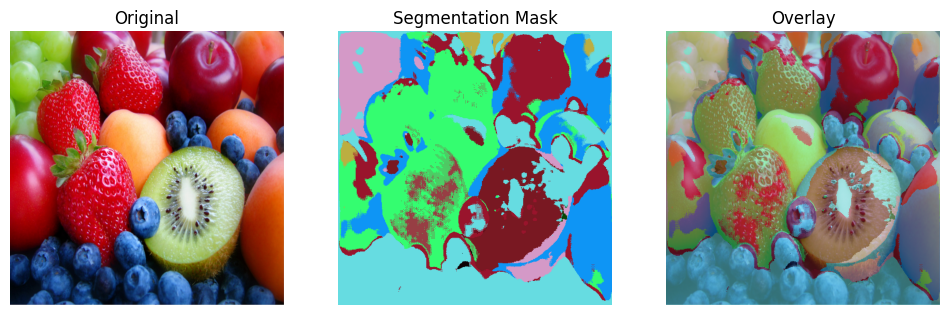

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import cv2
import numpy as np
import matplotlib.pyplot as plt


device = "cuda" if torch.cuda.is_available() else "cpu"


class UNetResNet34(nn.Module):
    def __init__(self, n_classes=31, pretrained=True):
        super().__init__()
        from torchvision.models import resnet34
        self.encoder = resnet34(pretrained=pretrained)
        self.encoder_layers = list(self.encoder.children())

    
        self.enc1 = nn.Sequential(*self.encoder_layers[:3])
        self.enc2 = nn.Sequential(*self.encoder_layers[3:5])
        self.enc3 = self.encoder_layers[5]
        self.enc4 = self.encoder_layers[6]
        self.enc5 = self.encoder_layers[7]

        self.up5 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec5 = nn.Conv2d(512, 256, 3, padding=1)
        self.up4 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec4 = nn.Conv2d(256, 128, 3, padding=1)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = nn.Conv2d(128, 64, 3, padding=1)
        self.up2 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec2 = nn.Conv2d(128, 64, 3, padding=1)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Conv2d(32, 32, 3, padding=1)

        self.final = nn.Conv2d(32, n_classes, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        d5 = self.up5(e5)
        d5 = self.dec5(torch.cat([d5, e4], dim=1))
        d4 = self.up4(d5)
        d4 = self.dec4(torch.cat([d4, e3], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e2], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e1], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(d1)

        out = self.final(d1)
        return out

BEST_MODEL_PATH = "/content/drive/MyDrive/FruitSegmentationModels/best_model.pth"
num_classes = 31

model = UNetResNet34(n_classes=num_classes)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
model.eval()

def preprocess_image(img_path, img_size=512):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_tensor = T.ToTensor()(img_resized).unsqueeze(0)  # batch
    return img_tensor.to(device), img_resized

def predict_image(img_path):
    img_tensor, img_resized = preprocess_image(img_path)
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        mask = torch.argmax(probs, dim=1).squeeze().cpu().numpy()
    return img_resized, mask

def visualize_mask(img, mask):
    colors = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)
    mask_color = colors[mask]
    overlay = cv2.addWeighted(img, 0.5, mask_color, 0.5, 0)

    plt.figure(figsize=(12, 12))
    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Segmentation Mask")
    plt.imshow(mask_color)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis('off')

    plt.show()

test_img_path = "/content/drive/MyDrive/R.jpg"
img, mask = predict_image(test_img_path)
visualize_mask(img, mask)
